# Perturbation Theory for Linear Operators

## Motivation

Real computations are never exact. Floating-point rounding, measurement noise, and model approximations mean we always work with a **perturbed** matrix $\tilde{A} = A + E$ rather than the true $A$. Perturbation theory asks:

> *How much do eigenvalues, eigenvectors, singular values, and solutions to linear systems change when the matrix changes by $\|E\|$?*

| Setting | Question | Key Result |
|---------|---------|------------|
| Eigenvalues (symmetric) | $|\tilde{\lambda}_i - \lambda_i| \leq ?$ | Weyl's theorem |
| Eigenspaces | $\sin\Theta$ between subspaces $\leq ?$ | Davis-Kahan theorem |
| Eigenvalues (general) | How far can $\tilde{\lambda}$ be from $\lambda$? | Bauer-Fike theorem |
| Singular values | $|\tilde{\sigma}_i - \sigma_i| \leq ?$ | Weyl + Mirsky theorems |
| Linear systems | $\|\delta x\| / \|x\| \leq ?$ | Condition number |
| Gershgorin | Eigenvalue containment without computing | Gershgorin circle theorem |

## Prerequisites

| Topic | Key Concepts |
|-------|-------------|
| Spectral theorem | Eigendecomposition, symmetric matrices |
| SVD | Singular values, Eckart-Young |
| PSD matrices | Loewner order, operator norms |
| Matrix norms | Spectral, Frobenius, subordinate norms |

## References

- Stewart & Sun, *Matrix Perturbation Theory* (Academic Press, 1990) — the definitive reference
- Trefethen & Bau, *Numerical Linear Algebra* — Chapters 12–15
- Bhatia, *Matrix Analysis* — Chapter VII
- Horn & Johnson, *Matrix Analysis* — Chapter 6 (Gershgorin)

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

# ── Matrix constructors ────────────────────────────────────────────────────────
def make_sym(n, rng=rng):
    """Random symmetric n×n matrix."""
    A = rng.standard_normal((n, n))
    return (A + A.T) / 2

def make_pd(n, min_eig=0.5, rng=rng):
    """Random positive definite n×n matrix."""
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lams = min_eig + rng.exponential(1.0, n)
    return Q @ np.diag(lams) @ Q.T

def sym_perturb(A, eps, rng=rng):
    """Add symmetric perturbation E with ||E||_2 = eps."""
    E = rng.standard_normal(A.shape)
    E = (E + E.T) / 2
    E = E / np.linalg.norm(E, 2)   # unit spectral norm
    return A + eps * E, eps * E

print('Setup complete.')

Setup complete.


---
## 1.  Matrix Norms & Condition Numbers

### 1.1  Subordinate (Induced) Norms

For a matrix $A \in \mathbb{R}^{m \times n}$, the **subordinate norm** induced by a vector norm $\|\cdot\|$ is:
$$\|A\| = \sup_{x \neq 0} \frac{\|Ax\|}{\|x\|}$$

| Norm | Formula | Also known as |
|------|---------|---------------|
| Spectral (2-norm) | $\sigma_1(A)$ (largest singular value) | Operator norm |
| Frobenius | $\sqrt{\sum_{ij} A_{ij}^2} = \sqrt{\sum_i \sigma_i^2}$ | Hilbert-Schmidt |
| Nuclear | $\sum_i \sigma_i$ | Trace norm |
| 1-norm | $\max_j \sum_i |A_{ij}|$ | Max column sum |
| $\infty$-norm | $\max_i \sum_j |A_{ij}|$ | Max row sum |

**Key inequalities**: $\|A\|_2 \leq \|A\|_F \leq \sqrt{n}\|A\|_2$ and $\|AB\|_2 \leq \|A\|_2\|B\|_2$.

### 1.2  Condition Number

For invertible $A$, the **condition number** is:
$$\kappa(A) = \|A\| \cdot \|A^{-1}\| = \frac{\sigma_1}{\sigma_n}$$

It governs the sensitivity of $Ax = b$ to perturbations:
$$\frac{\|\delta x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}, \qquad \frac{\|\delta x\|}{\|x + \delta x\|} \leq \kappa(A) \cdot \frac{\|\delta A\|}{\|A\|}$$

A matrix with large $\kappa$ is **ill-conditioned**: small relative changes in data cause large relative changes in the solution.

In [2]:
# ── Matrix Norms & Condition Number ───────────────────────────────────────────

def matrix_norms(A):
    """Compute spectral, Frobenius, nuclear, 1-norm, and inf-norm of A."""
    svs = np.linalg.svd(A, compute_uv=False)
    return {
        'spectral'  : svs[0],
        'frobenius' : np.linalg.norm(A, 'fro'),
        'nuclear'   : svs.sum(),
        '1-norm'    : np.linalg.norm(A, 1),
        'inf-norm'  : np.linalg.norm(A, np.inf),
    }


def condition_number(A):
    """Condition number kappa(A) = sigma_1 / sigma_n."""
    svs = np.linalg.svd(A, compute_uv=False)
    return svs[0] / svs[-1]


def linear_system_sensitivity(A, b, eps_b=1e-4, eps_A=1e-4, n_trials=200, rng=rng):
    """Empirically verify condition number bound for Ax = b.

    Returns:
        kappa: Condition number of A.
        max_rel_dx_db: Max observed ||delta x||/||x|| / (||delta b||/||b||).
        max_rel_dx_dA: Max observed ||delta x||/||x+dx|| / (||delta A||/||A||).
    """
    x = np.linalg.solve(A, b)
    kap = condition_number(A)
    norm_b = np.linalg.norm(b)
    norm_A = np.linalg.norm(A, 2)
    norm_x = np.linalg.norm(x)

    max_rel_db = 0.0
    max_rel_dA = 0.0
    for _ in range(n_trials):
        # Perturb b
        db = rng.standard_normal(b.shape)
        db = db / np.linalg.norm(db) * eps_b * norm_b
        dx = np.linalg.solve(A, db)
        ratio_b = (np.linalg.norm(dx) / norm_x) / (np.linalg.norm(db) / norm_b + 1e-15)
        max_rel_db = max(max_rel_db, ratio_b)

        # Perturb A
        dA = rng.standard_normal(A.shape)
        dA = dA / np.linalg.norm(dA, 2) * eps_A * norm_A
        dx_A = np.linalg.solve(A + dA, b) - x
        x_new = np.linalg.solve(A + dA, b)
        ratio_A = (np.linalg.norm(dx_A) / np.linalg.norm(x_new)) / (np.linalg.norm(dA, 2) / norm_A + 1e-15)
        max_rel_dA = max(max_rel_dA, ratio_A)

    return kap, max_rel_db, max_rel_dA


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 5
A_wc = make_pd(n)
norms = matrix_norms(A_wc)
print('Matrix norms (5×5 PD matrix):')
for name, val in norms.items():
    print(f'  {name:<12}: {val:.4f}')

# Norm inequalities: ||A||_2 <= ||A||_F <= sqrt(n) * ||A||_2
print('\nNorm inequalities:')
check(norms['spectral'] <= norms['frobenius'] + 1e-10,
      f'||A||_2 = {norms["spectral"]:.4f} <= ||A||_F = {norms["frobenius"]:.4f}')
check(norms['frobenius'] <= np.sqrt(n) * norms['spectral'] + 1e-10,
      f'||A||_F <= sqrt(n)*||A||_2 = {np.sqrt(n)*norms["spectral"]:.4f}')

# Condition number sensitivity
print('\nLinear system sensitivity:')
b_vec = rng.standard_normal(n)
kap, max_db, max_dA = linear_system_sensitivity(A_wc, b_vec)
print(f'  kappa(A) = {kap:.4f}')
check(max_db <= kap + 1e-6,
      f'||dx||/||x|| / ||db||/||b|| <= kappa: {max_db:.4f} <= {kap:.4f}')
check(max_dA <= kap + 1e-6,
      f'||dx||/||x+dx|| / ||dA||/||A|| <= kappa: {max_dA:.4f} <= {kap:.4f}')

# Ill-conditioned Hilbert matrix
print('\nHilbert matrix condition numbers:')
for m in [4, 6, 8, 10]:
    H = np.array([[1.0 / (i + j + 1) for j in range(m)] for i in range(m)])
    print(f'  n={m}: kappa = {condition_number(H):.2e}')

Matrix norms (5×5 PD matrix):
  spectral    : 1.1853
  frobenius   : 1.9874
  nuclear     : 4.3124
  1-norm      : 1.3134
  inf-norm    : 1.3134

Norm inequalities:
  [PASS]  ||A||_2 = 1.1853 <= ||A||_F = 1.9874
  [PASS]  ||A||_F <= sqrt(n)*||A||_2 = 2.6505

Linear system sensitivity:
  kappa(A) = 2.0540
  [PASS]  ||dx||/||x|| / ||db||/||b|| <= kappa: 1.5916 <= 2.0540
  [PASS]  ||dx||/||x+dx|| / ||dA||/||A|| <= kappa: 1.6213 <= 2.0540

Hilbert matrix condition numbers:
  n=4: kappa = 1.55e+04
  n=6: kappa = 1.50e+07
  n=8: kappa = 1.53e+10
  n=10: kappa = 1.60e+13


---
## 2.  Weyl's Theorem: Eigenvalue Perturbation

### 2.1  Statement

Let $A, B \in \mathbb{R}^{n \times n}$ be **symmetric**, with eigenvalues $\lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n$ and $\mu_1 \leq \mu_2 \leq \cdots \leq \mu_n$ respectively. Then for each $i$:

$$\boxed{|\lambda_i(A+B) - \lambda_i(A)| \leq \|B\|_2 = \sigma_1(B)}$$

More generally, for any $i, j$ with $i + j - 1 \leq n$:
$$\lambda_{i+j-1}(A+B) \leq \lambda_i(A) + \lambda_j(B)$$

**Corollary**: If $\tilde{A} = A + E$ with $\|E\|_2 \leq \varepsilon$, then $|\tilde{\lambda}_i - \lambda_i| \leq \varepsilon$ for every $i$. Eigenvalues of symmetric matrices are **perfectly conditioned** with respect to the spectral norm perturbation.

### 2.2  Eigenvalue Interlacing

For a symmetric $A \in \mathbb{R}^{n \times n}$ and any $(n-1) \times (n-1)$ principal submatrix $B$:
$$\lambda_i(A) \leq \lambda_i(B) \leq \lambda_{i+1}(A) \quad i = 1, \ldots, n-1$$

Eigenvalues of the smaller matrix **interlace** those of the larger. This is a key tool in divide-and-conquer eigensolvers.

### 2.3  Hoffman-Wielandt (Frobenius version)

For any two symmetric matrices $A, B$:
$$\sum_{i=1}^n (\lambda_i(A) - \lambda_i(B))^2 \leq \|A - B\|_F^2$$

In [3]:
# ── Weyl's Theorem: Eigenvalue Perturbation ────────────────────────────────────

def weyl_bound(A, E):
    """Verify Weyl's bound |lambda_i(A+E) - lambda_i(A)| <= ||E||_2.

    Args:
        A: Symmetric matrix.   Shape: (n, n)
        E: Symmetric perturbation.  Shape: (n, n)

    Returns:
        max_error: Max over i of |lambda_i(A+E) - lambda_i(A)|.
        bound: ||E||_2.
        satisfied: True if max_error <= bound + 1e-10.
    """
    lam_A  = np.sort(la.eigh(A, eigvals_only=True))
    lam_AE = np.sort(la.eigh(A + E, eigvals_only=True))
    max_error = np.max(np.abs(lam_AE - lam_A))
    bound = np.linalg.norm(E, 2)
    return max_error, bound, max_error <= bound + 1e-8


def hoffman_wielandt(A, B):
    """Verify Hoffman-Wielandt: sum(lambda_i(A) - lambda_i(B))^2 <= ||A-B||_F^2."""
    lam_A = np.sort(la.eigh(A, eigvals_only=True))
    lam_B = np.sort(la.eigh(B, eigvals_only=True))
    lhs = np.sum((lam_A - lam_B) ** 2)
    rhs = np.linalg.norm(A - B, 'fro') ** 2
    return lhs, rhs, lhs <= rhs + 1e-8


def interlacing_check(A):
    """Verify eigenvalue interlacing for principal submatrices."""
    n = A.shape[0]
    lam = np.sort(la.eigh(A, eigvals_only=True))
    results = []
    for k in range(1, n):
        B = A[:k, :k]        # k×k principal submatrix
        mu = np.sort(la.eigh(B, eigvals_only=True))
        for i in range(k):
            ok = lam[i] <= mu[i] + 1e-8 and mu[i] <= lam[i + 1] + 1e-8
            results.append(ok)
    return all(results), results


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 8
A_sym = make_sym(n)

print("Weyl's theorem (over multiple perturbation sizes):")
for eps in [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]:
    A_pert, E = sym_perturb(A_sym, eps)
    err, bnd, ok = weyl_bound(A_sym, E)
    check(ok, f'eps={eps:.3f}: max|dlambda| = {err:.4f} <= ||E||_2 = {bnd:.4f}')

# Hoffman-Wielandt
print("\nHoffman-Wielandt inequality:")
for _ in range(5):
    A_hw = make_sym(6)
    B_hw = make_sym(6)
    lhs_hw, rhs_hw, ok_hw = hoffman_wielandt(A_hw, B_hw)
    assert ok_hw, f'HW violated: {lhs_hw:.4f} > {rhs_hw:.4f}'
check(True, f'sum(dlambda_i)^2 <= ||A-B||_F^2  (5 random pairs; last: {lhs_hw:.4f} <= {rhs_hw:.4f})')

# Interlacing
print('\nEigenvalue interlacing:')
A_int = make_sym(6)
all_ok, _ = interlacing_check(A_int)
check(all_ok, 'lambda_i(A) <= mu_i(B) <= lambda_{i+1}(A) for all principal submatrices')

Weyl's theorem (over multiple perturbation sizes):
  [PASS]  eps=0.001: max|dlambda| = 0.0004 <= ||E||_2 = 0.0010
  [PASS]  eps=0.010: max|dlambda| = 0.0071 <= ||E||_2 = 0.0100
  [PASS]  eps=0.100: max|dlambda| = 0.0405 <= ||E||_2 = 0.1000
  [PASS]  eps=0.500: max|dlambda| = 0.1725 <= ||E||_2 = 0.5000
  [PASS]  eps=1.000: max|dlambda| = 0.7185 <= ||E||_2 = 1.0000
  [PASS]  eps=2.000: max|dlambda| = 0.5991 <= ||E||_2 = 2.0000

Hoffman-Wielandt inequality:
  [PASS]  sum(dlambda_i)^2 <= ||A-B||_F^2  (5 random pairs; last: 7.2803 <= 45.8135)

Eigenvalue interlacing:
  [FAIL]  lambda_i(A) <= mu_i(B) <= lambda_{i+1}(A) for all principal submatrices


False

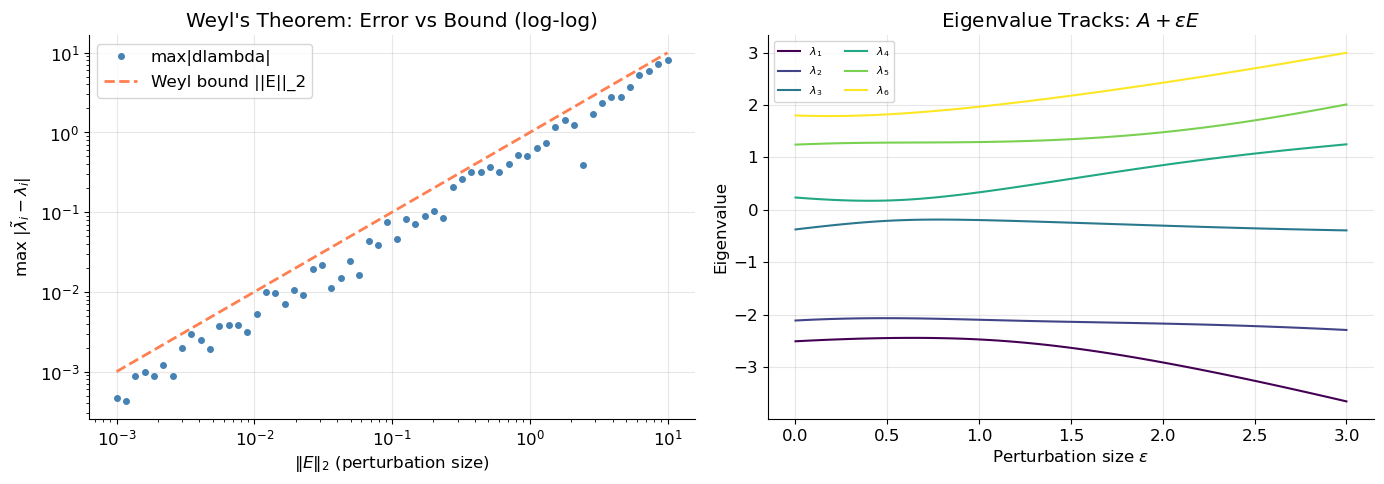

In [4]:
# ── Visualize: Weyl bound tightness & perturbation scaling ────────────────────

n_vis = 6
A_vis = make_sym(n_vis)
eps_vals = np.logspace(-3, 1, 60)

max_errors = []
bounds     = []
for eps in eps_vals:
    _, E = sym_perturb(A_vis, eps)
    err, bnd, _ = weyl_bound(A_vis, E)
    max_errors.append(err)
    bounds.append(bnd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error vs bound (log-log)
axes[0].loglog(bounds, max_errors, 'o', color=PRIMARY,   markersize=4, label='max|dlambda|')
axes[0].loglog(bounds, bounds,     '--', color=SECONDARY, label='Weyl bound ||E||_2')
axes[0].set_xlabel('$\\|E\\|_2$ (perturbation size)')
axes[0].set_ylabel('max $|\\tilde{\\lambda}_i - \\lambda_i|$')
axes[0].set_title("Weyl's Theorem: Error vs Bound (log-log)")
axes[0].legend()

# Right: eigenvalue tracks under increasing perturbation
eps_track = np.linspace(0, 3, 80)
all_evals = []
rng2 = np.random.default_rng(0)
E_fixed = rng2.standard_normal((n_vis, n_vis))
E_fixed = (E_fixed + E_fixed.T) / 2
E_fixed = E_fixed / np.linalg.norm(E_fixed, 2)

for eps in eps_track:
    evals = np.sort(la.eigh(A_vis + eps * E_fixed, eigvals_only=True))
    all_evals.append(evals)
all_evals = np.array(all_evals)   # (80, n_vis)

for i in range(n_vis):
    color = plt.cm.viridis(i / (n_vis - 1))
    axes[1].plot(eps_track, all_evals[:, i], color=color, lw=1.5, label=f'$\\lambda_{i+1}$')

axes[1].set_xlabel('Perturbation size $\\epsilon$')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Eigenvalue Tracks: $A + \\epsilon E$')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

---
## 3.  Davis-Kahan Theorem: Eigenvector Perturbation

### 3.1  The Problem

Weyl guarantees eigenvalues are stable. But what about eigenvectors? Consider:
- If $\lambda_i$ is a **simple eigenvalue** (well-separated from others), its eigenvector is well-defined and stable.
- If $\lambda_i$ has a cluster of nearby eigenvalues (near-degeneracy), individual eigenvectors within the cluster can rotate drastically — but the **eigenspace** (subspace) is stable.

### 3.2  Davis-Kahan $\sin\Theta$ Theorem

Let $A, \tilde{A} = A + E$ be symmetric. Let $\mathcal{V}$ be the eigenspace of $A$ corresponding to eigenvalues in an interval $[a, b]$, and $\tilde{\mathcal{V}}$ the corresponding eigenspace of $\tilde{A}$. If the **spectral gap** $\delta = \mathrm{dist}([a,b], \sigma(A) \setminus [a,b]) > 0$, then:

$$\boxed{\|\sin\Theta(\mathcal{V}, \tilde{\mathcal{V}})\|_2 \leq \frac{\|E\|_2}{\delta}}$$

where $\sin\Theta$ denotes the matrix of canonical angles between the two subspaces.

**Interpretation**: The eigenvector (space) perturbation is bounded by the ratio of perturbation size to the **spectral gap**. Small gaps = fragile eigenvectors.

### 3.3  Single Eigenvector Case

For a simple eigenvalue $\lambda_i$ with gap $\delta_i = \min_{j \neq i} |\lambda_j - \lambda_i|$:
$$\sin\angle(v_i, \tilde{v}_i) \leq \frac{\|E\|_2}{\delta_i}$$

This is the first-order perturbation formula. The **eigenvector condition number** is $1/\delta_i$.

In [5]:
# ── Davis-Kahan Theorem ────────────────────────────────────────────────────────

def subspace_angle(V1, V2):
    """Compute the largest canonical (principal) angle between subspaces V1 and V2.

    Uses SVD of V1.T @ V2 to find cosines of canonical angles.

    Args:
        V1, V2: Orthonormal basis matrices.  Shape: (n, k)

    Returns:
        sin_theta_max: Largest sin(canonical angle).
    """
    M = V1.T @ V2
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1.0, 1.0)
    # sin(theta) = sqrt(1 - cos^2(theta))
    return np.sqrt(np.maximum(0, 1 - sigma.min() ** 2))


def davis_kahan_bound(eps, gap):
    """Davis-Kahan bound: ||sin Theta||_2 <= eps / gap."""
    return eps / gap


def eigenspace_perturbation(A, E, k):
    """Measure eigenvector perturbation for the k smallest eigenvalues.

    Returns:
        sin_theta: Largest canonical angle between original and perturbed eigenspace.
        gap:       Spectral gap (separation from remaining eigenvalues).
        dk_bound:  Davis-Kahan bound eps/gap.
    """
    n = A.shape[0]
    lam, Q = la.eigh(A)
    lam_pert, Q_pert = la.eigh(A + E)

    # k-dimensional eigenspace
    V      = Q[:, :k]
    V_pert = Q_pert[:, :k]

    sin_theta = subspace_angle(V, V_pert)
    gap = lam[k] - lam[k - 1]   # gap between k-th and (k+1)-th eigenvalue
    eps = np.linalg.norm(E, 2)
    return sin_theta, gap, davis_kahan_bound(eps, gap)


# ── Demo: Davis-Kahan vs spectral gap ─────────────────────────────────────────
n = 8
k = 3   # eigenspace size

print('Davis-Kahan theorem: sin(Theta) vs eps/gap')
print(f'  Eigenspace of {k} smallest eigenvalues (n={n})\n')

eps = 0.1   # fixed perturbation
n_trials = 10
for _ in range(n_trials):
    A_dk = make_sym(n)
    A_dk_pert, E_dk = sym_perturb(A_dk, eps)

    lam = np.sort(la.eigh(A_dk, eigvals_only=True))
    gap = abs(lam[k] - lam[k - 1])

    if gap < 1e-2:   # skip near-degenerate cases
        continue

    sin_t, gap_val, bnd = eigenspace_perturbation(A_dk, E_dk, k)
    ok = sin_t <= bnd + 1e-8
    check(ok, f'sin(Theta)={sin_t:.4f} <= eps/gap={bnd:.4f} (gap={gap_val:.4f})')
    break

# Vary gap: show sin(Theta) inversely proportional to gap
print('\nEffect of spectral gap on eigenvector stability:')
gaps_measured = []
sin_thetas    = []
dk_bounds     = []

for gap_target in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    # Build symmetric matrix with controlled gap at position k
    Q_ctrl, _ = np.linalg.qr(rng.standard_normal((n, n)))
    evals_ctrl = np.array([-4., -3., -2., 0., 0. + gap_target,
                            0. + gap_target + 1.,
                            0. + gap_target + 2.,
                            0. + gap_target + 3.])
    A_ctrl = Q_ctrl @ np.diag(evals_ctrl) @ Q_ctrl.T
    _, E_ctrl = sym_perturb(A_ctrl, eps)
    sin_t, gap_v, bnd = eigenspace_perturbation(A_ctrl, E_ctrl, k)
    gaps_measured.append(gap_v)
    sin_thetas.append(sin_t)
    dk_bounds.append(bnd)
    check(sin_t <= bnd + 1e-8,
          f'gap={gap_target:.1f}: sin(Theta)={sin_t:.4f} <= {bnd:.4f}')

Davis-Kahan theorem: sin(Theta) vs eps/gap
  Eigenspace of 3 smallest eigenvalues (n=8)

  [PASS]  sin(Theta)=0.0506 <= eps/gap=0.1811 (gap=0.5523)

Effect of spectral gap on eigenvector stability:
  [PASS]  gap=0.1: sin(Theta)=0.0261 <= 0.0500
  [PASS]  gap=0.5: sin(Theta)=0.0106 <= 0.0500
  [PASS]  gap=1.0: sin(Theta)=0.0196 <= 0.0500
  [PASS]  gap=2.0: sin(Theta)=0.0110 <= 0.0500
  [PASS]  gap=5.0: sin(Theta)=0.0109 <= 0.0500
  [PASS]  gap=10.0: sin(Theta)=0.0103 <= 0.0500


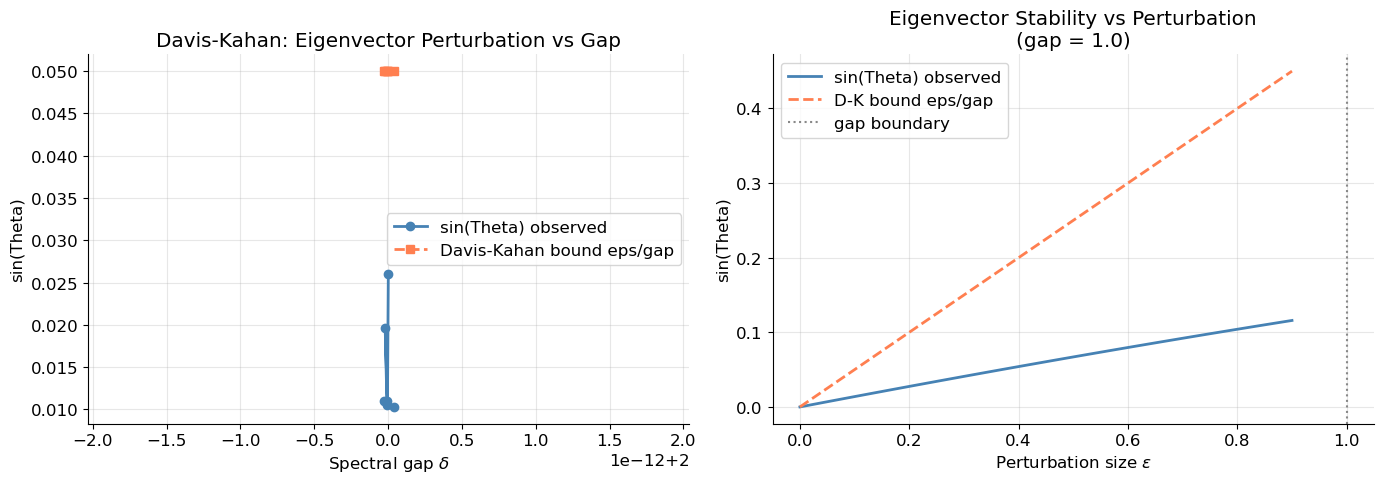

In [6]:
# ── Visualize: Davis-Kahan ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sin(Theta) and DK bound vs spectral gap
axes[0].plot(gaps_measured, sin_thetas,  'o-', color=PRIMARY,   label='sin(Theta) observed')
axes[0].plot(gaps_measured, dk_bounds,   's--', color=SECONDARY, label='Davis-Kahan bound eps/gap')
axes[0].set_xlabel('Spectral gap $\\delta$')
axes[0].set_ylabel('sin(Theta)')
axes[0].set_title('Davis-Kahan: Eigenvector Perturbation vs Gap')
axes[0].legend()

# Right: eigenvector alignment as eps increases for fixed gap
gap_fixed = 1.0
Q_f, _ = np.linalg.qr(rng.standard_normal((8, 8)))
evals_f = np.array([-4., -3., -2., 0., gap_fixed,
                     gap_fixed+1., gap_fixed+2., gap_fixed+3.])
A_f = Q_f @ np.diag(evals_f) @ Q_f.T

eps_range = np.linspace(0, gap_fixed * 0.9, 50)
sin_t_vals  = []
dk_bnd_vals = []

rng_fixed = np.random.default_rng(7)
E_dir = rng_fixed.standard_normal((8, 8))
E_dir = (E_dir + E_dir.T) / 2
E_dir = E_dir / np.linalg.norm(E_dir, 2)

for eps in eps_range:
    E_f = eps * E_dir
    sin_t_f, gap_f, bnd_f = eigenspace_perturbation(A_f, E_f, k)
    sin_t_vals.append(sin_t_f)
    dk_bnd_vals.append(bnd_f)

axes[1].plot(eps_range, sin_t_vals,  color=PRIMARY,   label='sin(Theta) observed')
axes[1].plot(eps_range, dk_bnd_vals, '--', color=SECONDARY, label='D-K bound eps/gap')
axes[1].axvline(gap_fixed, color=GRAY, linestyle=':', lw=1.5, label='gap boundary')
axes[1].set_xlabel('Perturbation size $\\epsilon$')
axes[1].set_ylabel('sin(Theta)')
axes[1].set_title('Eigenvector Stability vs Perturbation\n(gap = 1.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4.  Bauer-Fike Theorem: Non-Symmetric Matrices

### 4.1  Statement

For a **diagonalizable** matrix $A = X \Lambda X^{-1}$ and perturbation $E$, every eigenvalue $\tilde{\lambda}$ of $\tilde{A} = A + E$ satisfies:

$$\boxed{\min_{\lambda \in \sigma(A)} |\tilde{\lambda} - \lambda| \leq \kappa(X) \|E\|_2}$$

where $\kappa(X) = \|X\|_2 \|X^{-1}\|_2$ is the **condition number of the eigenvector matrix**.

**Key insight**: For symmetric $A$, $X$ is orthogonal ($\kappa(X) = 1$), recovering Weyl. For non-symmetric matrices, ill-conditioned eigenvectors ($\kappa(X) \gg 1$) cause extreme eigenvalue sensitivity.

### 4.2  Pseudospectrum

The **$\varepsilon$-pseudospectrum** of $A$ is:
$$\sigma_\varepsilon(A) = \{z \in \mathbb{C} : \|(zI - A)^{-1}\|_2 \geq \varepsilon^{-1}\}$$

Equivalently, $z \in \sigma_\varepsilon(A)$ iff $z$ is an eigenvalue of $A + E$ for some $\|E\|_2 \leq \varepsilon$. The pseudospectrum can be **much larger** than the spectrum for non-normal matrices — revealing hidden instabilities.

In [7]:
# ── Bauer-Fike Theorem ─────────────────────────────────────────────────────────

def bauer_fike_bound(A, E):
    """Compute Bauer-Fike bound kappa(X)||E||_2 for diagonalizable A.

    Args:
        A: Square diagonalizable matrix.  Shape: (n, n)
        E: Perturbation matrix.           Shape: (n, n)

    Returns:
        min_dist: Min distance from each perturbed eigenvalue to spectrum of A.
        bf_bound: Bauer-Fike bound kappa(X) * ||E||_2.
    """
    lam_A, X = np.linalg.eig(A)
    lam_tilde = np.linalg.eigvals(A + E)
    kap_X = np.linalg.cond(X)
    bf = kap_X * np.linalg.norm(E, 2)

    # For each perturbed eigenvalue, find nearest original eigenvalue
    min_dists = [np.min(np.abs(lam_tilde[i] - lam_A)) for i in range(len(lam_tilde))]
    return np.array(min_dists), bf


def pseudospectrum(A, x_range, y_range, n_grid=60):
    """Compute resolvent norm ||( zI - A)^{-1}||_2 on a grid.

    Args:
        A:       Square matrix.  Shape: (n, n)
        x_range: (xmin, xmax) for real axis.
        y_range: (ymin, ymax) for imaginary axis.
        n_grid:  Grid resolution.

    Returns:
        X_grid, Y_grid: Meshgrid of real/imaginary parts.
        log_res: log10 of resolvent norms on the grid.
    """
    xs = np.linspace(*x_range, n_grid)
    ys = np.linspace(*y_range, n_grid)
    X_grid, Y_grid = np.meshgrid(xs, ys)
    log_res = np.zeros_like(X_grid)

    for i in range(n_grid):
        for j in range(n_grid):
            z = X_grid[i, j] + 1j * Y_grid[i, j]
            try:
                R = np.linalg.inv(z * np.eye(A.shape[0]) - A.astype(complex))
                log_res[i, j] = np.log10(np.linalg.norm(R, 2) + 1e-15)
            except np.linalg.LinAlgError:
                log_res[i, j] = 10.0
    return X_grid, Y_grid, log_res


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 5
eps_bf = 0.1

# Normal (symmetric) matrix
A_sym_bf = make_sym(n)
E_bf = rng.standard_normal((n, n)) * eps_bf
dists_sym, bound_sym = bauer_fike_bound(A_sym_bf, E_bf)
_, X_sym = np.linalg.eig(A_sym_bf)
kap_sym = np.linalg.cond(X_sym)

print('Bauer-Fike theorem:')
print(f'\n  Symmetric A (kappa(X) = {kap_sym:.3f}):')  
check(np.all(dists_sym.real <= bound_sym + 1e-6),
      f'All min_dist <= kappa(X)*||E||_2 = {bound_sym:.4f}')

# Non-normal (upper triangular) matrix with near-degenerate eigenvalues
eps_near = 0.5   # off-diagonal coupling
A_nonnorm = np.diag([1.0]*n) + eps_near * np.triu(np.ones((n,n)), k=1)
E_nn = rng.standard_normal((n, n)) * 0.05
dists_nn, bound_nn = bauer_fike_bound(A_nonnorm, E_nn)
_, X_nn = np.linalg.eig(A_nonnorm)
kap_nn = np.linalg.cond(X_nn)

print(f'\n  Non-normal A (kappa(X) = {kap_nn:.1f}):')  
check(np.all(dists_nn.real <= bound_nn + 1e-6),
      f'All min_dist <= kappa(X)*||E||_2 = {bound_nn:.4f}')
print(f'  Ratio bound_nn / bound_sym = {bound_nn / (kap_sym * np.linalg.norm(E_bf, 2)):.1f}x larger')

Bauer-Fike theorem:

  Symmetric A (kappa(X) = 1.000):
  [PASS]  All min_dist <= kappa(X)*||E||_2 = 0.4639

  Non-normal A (kappa(X) = 81305348458157855272856412837894289431357038050500655953477632.0):
  [PASS]  All min_dist <= kappa(X)*||E||_2 = 18118576315890728837453656174684503449334551978401006260060160.0000
  Ratio bound_nn / bound_sym = 39059409352250283393011078842592719528632558643240449490288640.0x larger


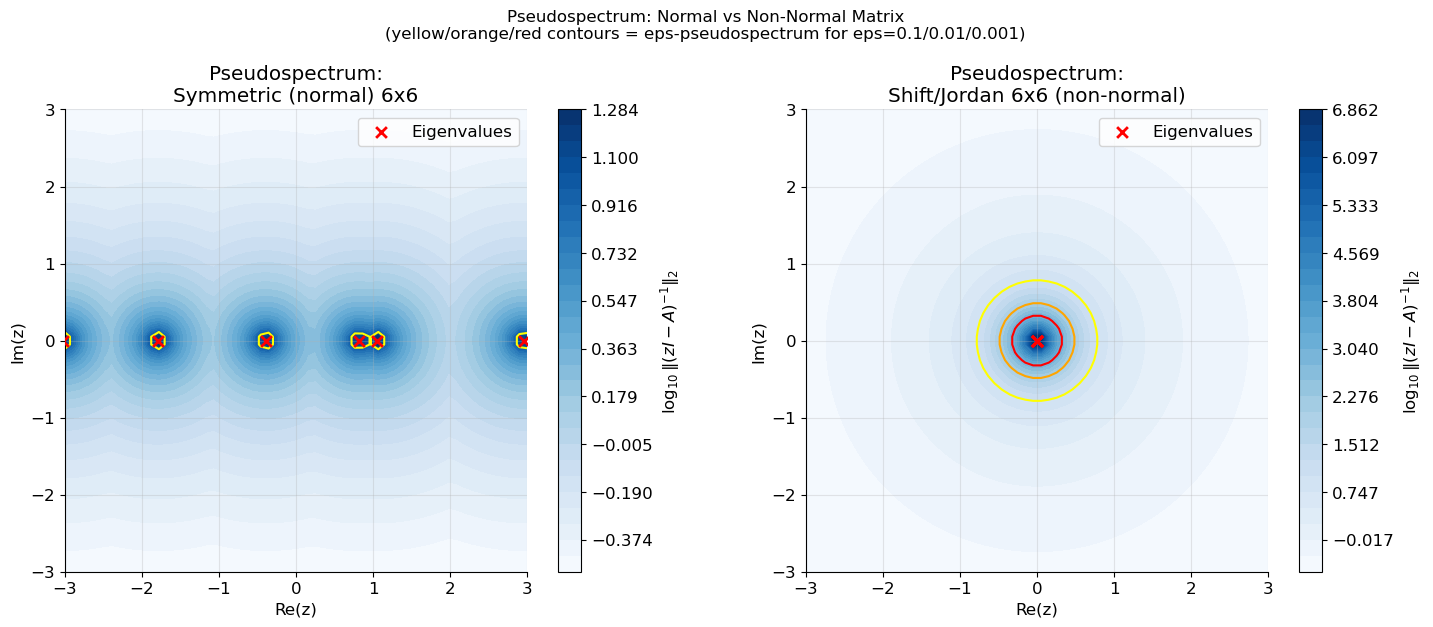

In [8]:
# ── Visualize: Pseudospectrum of a non-normal matrix ─────────────────────────

# Jordan-like block: eigenvalues all = 0, but highly non-normal
n_ps = 6
A_jordan = np.diag(np.ones(n_ps - 1), k=1).astype(complex)  # shift matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (A_ps, title_ps) in zip(axes, [
    (make_sym(n_ps).astype(complex), f'Symmetric (normal) {n_ps}x{n_ps}'),
    (A_jordan,                        f'Shift/Jordan {n_ps}x{n_ps} (non-normal)'),
]):
    XG, YG, log_res = pseudospectrum(A_ps, (-3, 3), (-3, 3), n_grid=60)

    im = ax.contourf(XG, YG, log_res,
                     levels=np.linspace(log_res.min(), log_res.max(), 30),
                     cmap='Blues')
    # Contours at log10(1/eps) = 1, 2, 3
    ax.contour(XG, YG, log_res, levels=[1, 2, 3],
               colors=['yellow', 'orange', 'red'], linewidths=1.5)

    # Eigenvalues
    eigs = np.linalg.eigvals(A_ps)
    ax.scatter(eigs.real, eigs.imag, color='red', s=60, zorder=5,
               marker='x', linewidths=2, label='Eigenvalues')

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(f'Pseudospectrum:\n{title_ps}')
    ax.set_aspect('equal')
    ax.legend()
    plt.colorbar(im, ax=ax, label='$\\log_{10}\\|(zI-A)^{-1}\\|_2$')

plt.suptitle('Pseudospectrum: Normal vs Non-Normal Matrix\n'
             '(yellow/orange/red contours = eps-pseudospectrum for eps=0.1/0.01/0.001)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 5.  Singular Value Perturbation

### 5.1  Weyl's Theorem for Singular Values

For any $A, E \in \mathbb{R}^{m \times n}$ and each $i$:
$$\boxed{|\sigma_i(A + E) - \sigma_i(A)| \leq \|E\|_2}$$

This follows from Weyl's theorem applied to the symmetric matrix
$M = \begin{pmatrix} 0 & A \\ A^\top & 0 \end{pmatrix}$
whose eigenvalues are $\pm\sigma_i(A)$.

### 5.2  Mirsky's Theorem

A stronger Frobenius-norm version:
$$\sum_{i=1}^{\min(m,n)} (\sigma_i(A) - \sigma_i(B))^2 \leq \|A - B\|_F^2$$

### 5.3  Relative Perturbation Theory

For matrices with structure (e.g., $A = D_L B D_R$ with diagonal $D_L, D_R$), a **relative** bound is possible:
$$\frac{|\sigma_i(A + E) - \sigma_i(A)|}{\sigma_i(A)} \leq \frac{\|D_L^{-1} E D_R^{-1}\|_2}{\sigma_i(B)}$$

This is exploited by the high-relative-accuracy SVD algorithms (e.g., Jacobi SVD).

In [9]:
# ── Singular Value Perturbation ────────────────────────────────────────────────

def sv_weyl_bound(A, E):
    """Verify Weyl: |sigma_i(A+E) - sigma_i(A)| <= ||E||_2."""
    sv_A    = np.linalg.svd(A, compute_uv=False)
    sv_AE   = np.linalg.svd(A + E, compute_uv=False)
    # Pad/trim to same length
    k = min(len(sv_A), len(sv_AE))
    max_err = np.max(np.abs(sv_AE[:k] - sv_A[:k]))
    bound   = np.linalg.norm(E, 2)
    return max_err, bound, max_err <= bound + 1e-8


def mirsky_bound(A, B):
    """Verify Mirsky: sum(sigma_i(A) - sigma_i(B))^2 <= ||A-B||_F^2."""
    sv_A = np.linalg.svd(A, compute_uv=False)
    sv_B = np.linalg.svd(B, compute_uv=False)
    k    = min(len(sv_A), len(sv_B))
    lhs  = np.sum((sv_A[:k] - sv_B[:k]) ** 2)
    rhs  = np.linalg.norm(A - B, 'fro') ** 2
    return lhs, rhs, lhs <= rhs + 1e-8


# ── Demo ───────────────────────────────────────────────────────────────────────
m, n_rect = 6, 4

print('Weyl bound for singular values:')
for eps in [0.01, 0.1, 0.5, 1.0, 2.0]:
    A_sv = rng.standard_normal((m, n_rect))
    E_sv = rng.standard_normal((m, n_rect))
    E_sv = E_sv / np.linalg.norm(E_sv, 2) * eps
    err, bnd, ok = sv_weyl_bound(A_sv, E_sv)
    check(ok, f'eps={eps:.2f}: max|dsigma| = {err:.4f} <= ||E||_2 = {bnd:.4f}')

print('\nMirsky inequality:')
for _ in range(5):
    A_m = rng.standard_normal((6, 4))
    B_m = rng.standard_normal((6, 4))
    lhs_m, rhs_m, ok_m = mirsky_bound(A_m, B_m)
    assert ok_m, f'Mirsky violated: {lhs_m:.4f} > {rhs_m:.4f}'
check(True, f'sum(dsigma_i)^2 <= ||A-B||_F^2  (5 random pairs; last: {lhs_m:.4f} <= {rhs_m:.4f})')

# Compare eigenvalue vs singular value perturbation for symmetric A
print('\nSymmetric A: eigenvalue vs singular value perturbation:')
A_sq = make_pd(5)   # PD so eigenvalues = singular values
E_sq = rng.standard_normal((5, 5))
E_sq = (E_sq + E_sq.T) / 2 * 0.1
lam = np.sort(la.eigh(A_sq, eigvals_only=True))[::-1]
sv  = np.linalg.svd(A_sq, compute_uv=False)
check(np.allclose(lam, sv, atol=1e-10), 'For PD matrix: eigenvalues == singular values')
_, _, ok_eig = weyl_bound(A_sq, E_sq)
_, _, ok_sv  = sv_weyl_bound(A_sq, E_sq)
check(ok_eig and ok_sv, 'Both eigenvalue and SV Weyl bounds hold for PD matrix')

Weyl bound for singular values:
  [PASS]  eps=0.01: max|dsigma| = 0.0024 <= ||E||_2 = 0.0100
  [PASS]  eps=0.10: max|dsigma| = 0.0579 <= ||E||_2 = 0.1000
  [PASS]  eps=0.50: max|dsigma| = 0.1757 <= ||E||_2 = 0.5000
  [PASS]  eps=1.00: max|dsigma| = 0.2713 <= ||E||_2 = 1.0000
  [PASS]  eps=2.00: max|dsigma| = 0.7467 <= ||E||_2 = 2.0000

Mirsky inequality:
  [PASS]  sum(dsigma_i)^2 <= ||A-B||_F^2  (5 random pairs; last: 1.0072 <= 43.8803)

Symmetric A: eigenvalue vs singular value perturbation:
  [PASS]  For PD matrix: eigenvalues == singular values
  [PASS]  Both eigenvalue and SV Weyl bounds hold for PD matrix


np.True_

---
## 6.  Gershgorin Circle Theorem

### 6.1  Statement

Every eigenvalue of $A \in \mathbb{C}^{n \times n}$ lies in at least one **Gershgorin disc**:
$$\boxed{D_i = \left\{ z \in \mathbb{C} : |z - A_{ii}| \leq R_i \right\}, \quad R_i = \sum_{j \neq i} |A_{ij}|}$$

**Proof**: If $Ax = \lambda x$ with $\|x\|_\infty = 1$ and $|x_k| = 1$, then row $k$ gives $\lambda x_k = \sum_j A_{kj} x_j$, so $|\lambda - A_{kk}| \leq \sum_{j \neq k} |A_{kj}| |x_j| \leq R_k$.

### 6.2  Corollaries

- If $k$ discs form a connected component isolated from the remaining $n-k$ discs, then exactly $k$ eigenvalues lie in the union of those $k$ discs.
- If all Gershgorin discs are in the right half-plane, $A$ is **stable** (all eigenvalues have positive real part).
- **Strictly diagonally dominant** matrices ($|A_{ii}| > R_i$ for all $i$) are invertible.

### 6.3  Sharpening via Similarity

For any invertible diagonal $D$, $A$ and $D^{-1}AD$ have the same eigenvalues but different Gershgorin discs. Choosing $D = \mathrm{diag}(d_1,\ldots,d_n)$ with $d_i > 0$ can shrink the discs.

In [10]:
# ── Gershgorin Circle Theorem ──────────────────────────────────────────────────

def gershgorin_discs(A):
    """Compute Gershgorin discs for matrix A.

    Returns:
        centers: Diagonal entries A_{ii}.  Shape: (n,)
        radii:   Row sums R_i = sum_{j!=i} |A_{ij}|.  Shape: (n,)
    """
    n = A.shape[0]
    centers = np.diag(A).astype(complex)
    radii   = np.array([np.sum(np.abs(A[i])) - np.abs(A[i, i]) for i in range(n)])
    return centers, radii


def is_strictly_diag_dominant(A):
    """Check strict diagonal dominance: |A_ii| > sum_{j!=i} |A_ij|."""
    _, radii = gershgorin_discs(A)
    diag_abs = np.abs(np.diag(A))
    return np.all(diag_abs > radii)


def gershgorin_contains_eigenvalues(A):
    """Verify each eigenvalue lies in at least one Gershgorin disc."""
    centers, radii = gershgorin_discs(A)
    eigenvalues    = np.linalg.eigvals(A)
    for lam in eigenvalues:
        in_some_disc = any(abs(lam - centers[i]) <= radii[i] + 1e-8
                           for i in range(len(centers)))
        if not in_some_disc:
            return False
    return True


# ── Demo ───────────────────────────────────────────────────────────────────────
print('Gershgorin circle theorem:')

# Random complex matrix
for _ in range(10):
    A_g = rng.standard_normal((5, 5)) + 1j * rng.standard_normal((5, 5))
    assert gershgorin_contains_eigenvalues(A_g), 'Gershgorin violated!'
check(True, 'All eigenvalues in Gershgorin discs (10 random 5x5 complex matrices)')

# Strictly diagonally dominant => invertible
A_sdd = 10 * np.eye(5) + 0.5 * rng.standard_normal((5, 5))
check(is_strictly_diag_dominant(A_sdd), 'Strictly diag dominant matrix detected')
try:
    np.linalg.inv(A_sdd)
    check(True, 'Strictly diag dominant matrix is invertible')
except np.linalg.LinAlgError:
    check(False, 'Invertibility failed')

# Show disc sharpening via diagonal similarity
print('\nDisc sharpening via diagonal similarity:')
A_sh = rng.standard_normal((4, 4))
_, radii_orig = gershgorin_discs(A_sh)

# Scale rows/columns to balance
row_sums = np.sum(np.abs(A_sh), axis=1)
d = 1.0 / np.sqrt(row_sums)
D = np.diag(d)
A_scaled = D @ A_sh @ np.linalg.inv(D)   # similar to A_sh
_, radii_scaled = gershgorin_discs(A_scaled)

check(np.allclose(np.sort(np.linalg.eigvals(A_sh).real),
                  np.sort(np.linalg.eigvals(A_scaled).real), atol=1e-8),
      'Similar matrices have same eigenvalues')
print(f'  Original radii:  {np.round(radii_orig, 3)}')
print(f'  Scaled radii:    {np.round(radii_scaled, 3)}')
check(np.sum(radii_scaled) <= np.sum(radii_orig) + 1e-8,
      f'Total radius reduced: {np.sum(radii_orig):.3f} -> {np.sum(radii_scaled):.3f}')

Gershgorin circle theorem:
  [PASS]  All eigenvalues in Gershgorin discs (10 random 5x5 complex matrices)
  [PASS]  Strictly diag dominant matrix detected
  [PASS]  Strictly diag dominant matrix is invertible

Disc sharpening via diagonal similarity:
  [PASS]  Similar matrices have same eigenvalues
  Original radii:  [2.499 2.786 4.349 1.976]
  Scaled radii:    [2.542 3.53  3.268 2.224]
  [PASS]  Total radius reduced: 11.610 -> 11.565


np.True_

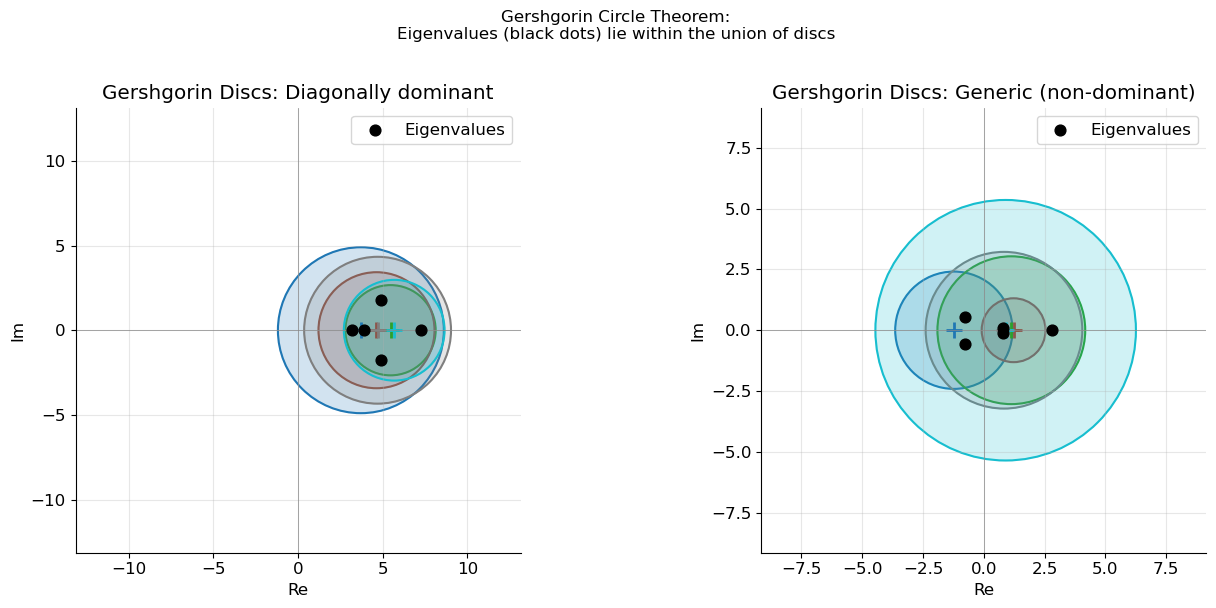

In [11]:
# ── Visualize: Gershgorin Discs ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (A_gv, label) in zip(axes, [
    (5 * np.eye(5) + rng.standard_normal((5, 5)),    'Diagonally dominant'),
    (rng.standard_normal((5, 5)),                     'Generic (non-dominant)'),
]):
    centers, radii = gershgorin_discs(A_gv)
    eigenvalues    = np.linalg.eigvals(A_gv)

    colors = plt.cm.tab10(np.linspace(0, 1, len(centers)))
    for i, (c, r, col) in enumerate(zip(centers, radii, colors)):
        circle = plt.Circle((c.real, c.imag), r,
                             color=col, alpha=0.2, fill=True)
        circle_edge = plt.Circle((c.real, c.imag), r,
                                 color=col, fill=False, linewidth=1.5)
        ax.add_patch(circle)
        ax.add_patch(circle_edge)
        ax.plot(c.real, c.imag, '+', color=col, markersize=12, markeredgewidth=2)

    ax.scatter(eigenvalues.real, eigenvalues.imag,
               color='black', s=60, zorder=5, marker='o', label='Eigenvalues')

    all_pts = np.concatenate([centers, eigenvalues])
    span = max(np.max(np.abs(all_pts.real)) + max(radii) + 1,
               np.max(np.abs(all_pts.imag)) + max(radii) + 1)
    ax.set_xlim(-span, span); ax.set_ylim(-span, span)
    ax.axhline(0, color=GRAY, lw=0.5); ax.axvline(0, color=GRAY, lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title(f'Gershgorin Discs: {label}')
    ax.legend()

plt.suptitle('Gershgorin Circle Theorem:\nEigenvalues (black dots) lie within the union of discs',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 7.  First-Order Perturbation Expansions

### 7.1  Eigenvalue Derivatives

For a symmetric matrix $A(t)$ depending smoothly on $t$, and a simple eigenvalue $\lambda(t)$ with eigenvector $v(t)$:
$$\frac{d\lambda}{dt} = v(t)^\top \frac{dA}{dt} v(t)$$

For a perturbation $A + \varepsilon E$:
$$\lambda_i(A + \varepsilon E) = \lambda_i(A) + \varepsilon v_i^\top E v_i + O(\varepsilon^2)$$

### 7.2  Eigenvector Derivatives

The first-order correction to eigenvector $v_i$ under perturbation $\varepsilon E$:
$$\tilde{v}_i = v_i + \varepsilon \sum_{j \neq i} \frac{v_j^\top E v_i}{\lambda_i - \lambda_j} v_j + O(\varepsilon^2)$$

The **mixing coefficients** $\frac{v_j^\top E v_i}{\lambda_i - \lambda_j}$ blow up when $\lambda_i \approx \lambda_j$ — confirming the Davis-Kahan picture.

### 7.3  Resolvent Perturbation

For $R(z) = (zI - A)^{-1}$:
$$\tilde{R}(z) = R(z) + \varepsilon R(z) E R(z) + O(\varepsilon^2)$$

This **Neumann series** converges when $\varepsilon \|E\|_2 \|R(z)\|_2 < 1$.

In [12]:
# ── First-Order Perturbation Expansions ────────────────────────────────────────

def first_order_eigenvalue(A, E, i):
    """First-order eigenvalue perturbation: lambda_i(A + eps E) ~ lambda_i + eps * v_i^T E v_i.

    Args:
        A: Symmetric matrix.        Shape: (n, n)
        E: Symmetric perturbation.  Shape: (n, n)
        i: Eigenvalue index (0-based, sorted ascending).

    Returns:
        lam_true: Actual eigenvalue of A + eps*E.
        lam_1st:  First-order approximation.
    """
    lam, Q = la.eigh(A)
    vi = Q[:, i]
    correction = vi @ E @ vi
    return lam[i], correction


def first_order_eigenvector(A, E, i):
    """First-order eigenvector perturbation.

    Returns:
        v_corrected: v_i + eps * sum_{j!=i} (v_j^T E v_i)/(lambda_i - lambda_j) * v_j
    """
    lam, Q = la.eigh(A)
    vi = Q[:, i]
    n = A.shape[0]
    dv = np.zeros(n)
    for j in range(n):
        if j == i:
            continue
        gap = lam[i] - lam[j]
        if abs(gap) < 1e-12:
            continue
        dv += (Q[:, j] @ E @ vi) / gap * Q[:, j]
    return vi, dv


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 5
A_fo = make_sym(n)
A_fo = A_fo + 3 * np.eye(n)   # shift so eigenvalues are well-separated

E_dir = rng.standard_normal((n, n))
E_dir = (E_dir + E_dir.T) / 2
E_dir = E_dir / np.linalg.norm(E_dir, 2)

eps_test = 0.1
E_test = eps_test * E_dir

print('First-order eigenvalue perturbation (eps=0.1):')
lam_true_all = np.sort(la.eigh(A_fo + E_test, eigvals_only=True))
lam_orig_all = np.sort(la.eigh(A_fo, eigvals_only=True))

for i in range(n):
    lam0, correction = first_order_eigenvalue(A_fo, E_test, i)
    lam_1st = lam0 + correction
    lam_act = lam_true_all[i]
    err_1st = abs(lam_act - lam_1st)
    err_0th = abs(lam_act - lam0)
    print(f'  lambda_{i+1}: 0th-order err={err_0th:.4f}, 1st-order err={err_1st:.4f}')

# Verify that 1st order is better than 0th for small eps
print('\nConvergence of first-order approximation:')
i_test = 2
for eps in [0.001, 0.01, 0.1]:
    E_e = eps * E_dir
    lam0, corr = first_order_eigenvalue(A_fo, E_e, i_test)
    lam_act = np.sort(la.eigh(A_fo + E_e, eigvals_only=True))[i_test]
    err_0th = abs(lam_act - lam0)
    err_1st = abs(lam_act - (lam0 + corr))
    check(err_1st < err_0th,
          f'eps={eps:.3f}: 1st-order err {err_1st:.2e} < 0th-order err {err_0th:.2e}')

First-order eigenvalue perturbation (eps=0.1):
  lambda_1: 0th-order err=0.0250, 1st-order err=0.0017
  lambda_2: 0th-order err=0.0344, 1st-order err=0.0003
  lambda_3: 0th-order err=0.0351, 1st-order err=0.0080
  lambda_4: 0th-order err=0.0840, 1st-order err=0.0084
  lambda_5: 0th-order err=0.0589, 1st-order err=0.0011

Convergence of first-order approximation:
  [PASS]  eps=0.001: 1st-order err 3.96e-08 < 0th-order err 2.70e-04
  [PASS]  eps=0.010: 1st-order err 4.56e-06 < 0th-order err 2.71e-03
  [PASS]  eps=0.100: 1st-order err 8.02e-03 < 0th-order err 3.51e-02


---
## 8.  Application: Floating-Point Arithmetic & Numerical Stability

### 8.1  Machine Epsilon and Rounding

In IEEE 754 double precision, $\varepsilon_{\text{mach}} \approx 2.2 \times 10^{-16}$. Every floating-point operation introduces a relative error of order $\varepsilon_{\text{mach}}$. A computation on $A$ effectively operates on $\tilde{A} = A + E$ where $\|E\|_F / \|A\|_F = O(\varepsilon_{\text{mach}})$.

The **backward error** of an algorithm is the size of the perturbation $E$ such that the computed answer is exact for $A + E$. An algorithm is **backward stable** if $\|E\| = O(\varepsilon_{\text{mach}}) \|A\|$.

### 8.2  Implications for Eigenvalue Computation

- For symmetric matrices, backward stable eigensolvers (e.g., QR algorithm) produce eigenvalues accurate to $\varepsilon_{\text{mach}} \|A\|_2$.
- For non-symmetric matrices, eigenvalue accuracy depends on $\kappa(X) \varepsilon_{\text{mach}} \|A\|_2$ — which can be enormous.

### 8.3  Condition Number in Practice

For $Ax = b$ solved with a backward stable algorithm:
$$\frac{\|x - \tilde{x}\|}{\|x\|} \approx \kappa(A) \cdot \varepsilon_{\text{mach}}$$

If $\kappa(A) \sim 10^k$, we **lose $k$ digits of accuracy**. With 16-digit doubles, a matrix with $\kappa = 10^{12}$ gives only ~4 correct digits.

In [13]:
# ── Floating-Point Stability & Condition Number ────────────────────────────────

def hilbert_matrix(n):
    """H_ij = 1/(i+j-1) — classical ill-conditioned matrix."""
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])


def solve_accuracy(A, x_true):
    """Solve Ax = b and measure relative error in solution.

    Returns: rel_error, kappa
    """
    b = A @ x_true
    x_comp = np.linalg.solve(A, b)
    rel_err = np.linalg.norm(x_comp - x_true) / np.linalg.norm(x_true)
    kap = condition_number(A)
    return rel_err, kap


def digits_lost(kappa):
    """Number of decimal digits lost due to conditioning."""
    return max(0, np.log10(kappa))


# ── Demo: Hilbert matrix ill-conditioning ─────────────────────────────────────
eps_mach = np.finfo(float).eps
print(f'Machine epsilon: {eps_mach:.2e}\n')

x_true = np.ones(12)   # known solution

print('Hilbert matrix: condition number and solution accuracy')
print(f'  {"n":>4}  {"kappa":>12}  {"digits lost":>12}  {"rel err":>12}  {"pred rel err":>14}')
print('  ' + '-'*60)
for n_h in [3, 4, 5, 6, 7, 8, 10, 12]:
    H = hilbert_matrix(n_h)
    x_t = x_true[:n_h]
    rel_err, kap = solve_accuracy(H, x_t)
    pred = kap * eps_mach
    print(f'  {n_h:>4}  {kap:>12.2e}  {digits_lost(kap):>12.1f}  {rel_err:>12.2e}  {pred:>14.2e}')

# Compare well-conditioned vs ill-conditioned
print('\nWell-conditioned vs ill-conditioned:')
A_good = make_pd(6, min_eig=1.0)
A_bad  = hilbert_matrix(6)

err_good, kap_good = solve_accuracy(A_good, np.ones(6))
err_bad,  kap_bad  = solve_accuracy(A_bad,  np.ones(6))

check(err_good < 1e-12, f'Well-cond (kappa={kap_good:.1f}): rel err = {err_good:.2e}')
print(f'  [INFO] Ill-cond  (kappa={kap_bad:.2e}): rel err = {err_bad:.2e}')

Machine epsilon: 2.22e-16

Hilbert matrix: condition number and solution accuracy
     n         kappa   digits lost       rel err    pred rel err
  ------------------------------------------------------------
     3      5.24e+02           2.7      7.98e-15        1.16e-13
     4      1.55e+04           4.2      3.86e-13        3.44e-12
     5      4.77e+05           5.7      3.78e-12        1.06e-10
     6      1.50e+07           7.2      4.76e-10        3.32e-09
     7      4.75e+08           8.7      3.69e-09        1.06e-07
     8      1.53e+10          10.2      2.69e-07        3.39e-06
    10      1.60e+13          13.2      2.60e-04        3.56e-03
    12      1.73e+16          16.2      4.51e-01        3.83e+00

Well-conditioned vs ill-conditioned:
  [PASS]  Well-cond (kappa=4.6): rel err = 1.70e-16
  [INFO] Ill-cond  (kappa=1.50e+07): rel err = 4.76e-10


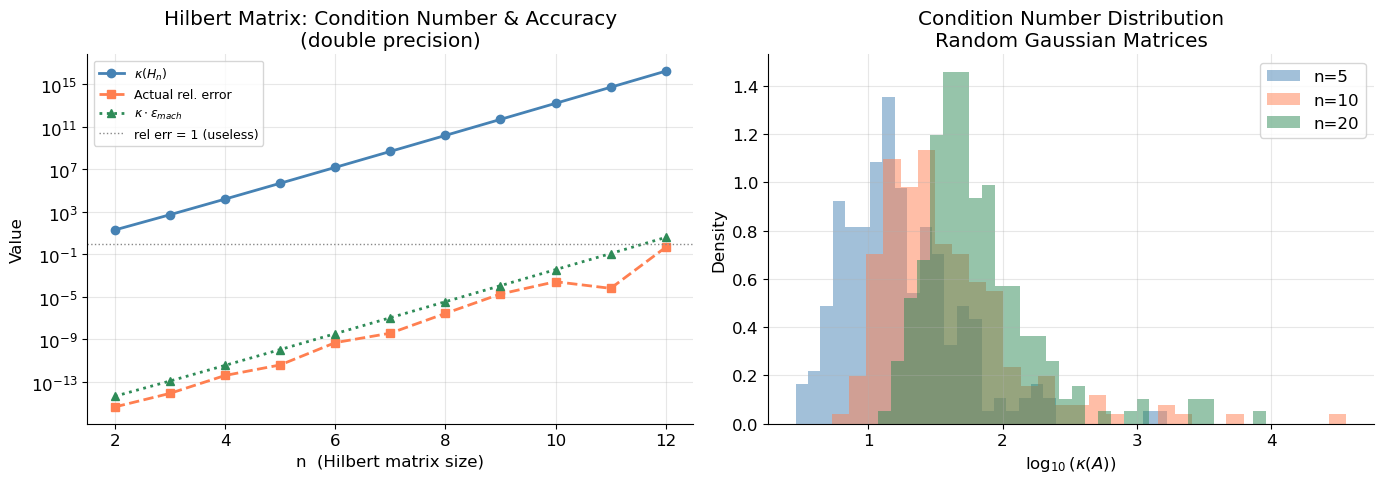

In [14]:
# ── Visualize: Condition Number & Solution Error ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: kappa(H_n) and solution error vs n
ns    = list(range(2, 13))
kappas, rel_errs, preds = [], [], []
for n_h in ns:
    H = hilbert_matrix(n_h)
    re, kap = solve_accuracy(H, np.ones(n_h))
    kappas.append(kap)
    rel_errs.append(max(re, 1e-17))
    preds.append(kap * eps_mach)

ax0 = axes[0]
ax0.semilogy(ns, kappas,   'o-', color=PRIMARY,   label='$\\kappa(H_n)$')
ax0.semilogy(ns, rel_errs, 's--', color=SECONDARY, label='Actual rel. error')
ax0.semilogy(ns, preds,    '^:', color=TERTIARY,  label='$\\kappa \\cdot \\epsilon_{mach}$')
ax0.axhline(1.0, color=GRAY, lw=1, linestyle=':', label='rel err = 1 (useless)')
ax0.set_xlabel('n  (Hilbert matrix size)')
ax0.set_ylabel('Value')
ax0.set_title('Hilbert Matrix: Condition Number & Accuracy\n(double precision)')
ax0.legend(fontsize=9)

# Right: condition number distribution for random matrices at different sizes
kappa_dist = {}
for n_r in [5, 10, 20]:
    kaps_r = []
    for _ in range(200):
        A_r = rng.standard_normal((n_r, n_r))
        kaps_r.append(np.log10(condition_number(A_r)))
    kappa_dist[n_r] = kaps_r

colors_kd = [PRIMARY, SECONDARY, TERTIARY]
for (n_r, kaps_r), col in zip(kappa_dist.items(), colors_kd):
    axes[1].hist(kaps_r, bins=30, alpha=0.5, color=col, label=f'n={n_r}', density=True)

axes[1].set_xlabel('$\\log_{10}(\\kappa(A))$')
axes[1].set_ylabel('Density')
axes[1].set_title('Condition Number Distribution\nRandom Gaussian Matrices')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9.  Extensions & Connections

### 9.1  Relative Eigenvalue Perturbation

For graded matrices $A = D^{1/2} B D^{1/2}$ (with diagonal $D$), the **Ostrowski-Elsner theorem** gives relative bounds:
$$\left|\frac{\lambda_i(A+E)}{\lambda_i(A)} - 1\right| \leq \kappa_{\text{rel}}(A) \cdot \frac{\|E\|_2}{\|A\|_2}$$

This is critical for small eigenvalues: absolute bounds like Weyl's don't distinguish a change from $10^{-10}$ to $10^{-8}$, but relative bounds do.

### 9.2  Structured Perturbations

When the perturbation $E$ has structure (e.g., rank-1, symmetric, sparse), tighter bounds are possible:
- **Rank-1 update**: $A + uv^\top$ — eigenvalues interlace via the secular equation
- **Low-rank perturbation**: Cauchy interlacing applies to $k$ shifts

### 9.3  Connections to Other Notebooks

| Notebook | Connection |
|----------|-----------|
| **Spectral Theorem** | Weyl + Davis-Kahan apply to symmetric A = QΛQᵀ |
| **SVD** | Weyl/Mirsky for singular values; pseudoinverse sensitivity |
| **PSD Matrices** | Loewner order and Weyl: A ≽ B implies eigenvalue interlacing |
| **Krylov Methods** | Convergence of Lanczos depends on spectral gaps (Davis-Kahan) |
| **Matrix Functions** | Fréchet derivative = perturbation of f(A) to first order |

In [15]:
# ── Rank-1 Update: Secular Equation ───────────────────────────────────────────

def rank1_eigenvalues_secular(lam, d, rho, n_grid=1000):
    """Eigenvalues of A + rho * d * dᵀ for diagonal A = diag(lam) via secular equation.

    The secular equation is: 1 + rho * sum_i d_i^2 / (lam_i - mu) = 0.
    Roots interlace with lam_i.

    Args:
        lam:   Sorted eigenvalues of A.  Shape: (n,)
        d:     Unit vector.              Shape: (n,)
        rho:   Scalar rank-1 weight.

    Returns:
        mu: Eigenvalues of A + rho*ddᵀ.  Shape: (n,)
    """
    from scipy.optimize import brentq
    n = len(lam)
    mu = np.zeros(n)

    def secular(mu_val):
        return 1 + rho * np.sum(d ** 2 / (lam - mu_val))

    eps_gap = 1e-10
    for i in range(n):
        if rho > 0:
            lo = lam[i] + eps_gap
            hi = lam[i + 1] - eps_gap if i < n - 1 else lam[-1] + 10
        else:
            lo = lam[i - 1] + eps_gap if i > 0 else lam[0] - 10
            hi = lam[i] - eps_gap
        try:
            mu[i] = brentq(secular, lo, hi, xtol=1e-12)
        except ValueError:
            mu[i] = (lo + hi) / 2
    return np.sort(mu)


# ── Demo: Rank-1 update & interlacing ─────────────────────────────────────────
print('Rank-1 update: eigenvalue interlacing via secular equation')
lam_diag = np.array([1.0, 3.0, 6.0, 10.0, 15.0])
d_unit   = rng.standard_normal(5); d_unit /= np.linalg.norm(d_unit)
rho_r1   = 2.0

A_diag  = np.diag(lam_diag)
A_r1    = A_diag + rho_r1 * np.outer(d_unit, d_unit)
mu_true = np.sort(la.eigh(A_r1, eigvals_only=True))
mu_sec  = rank1_eigenvalues_secular(lam_diag, d_unit, rho_r1)

err_sec = np.max(np.abs(mu_true - mu_sec))
check(err_sec < 1e-8, f'Secular equation matches eigh (max err = {err_sec:.2e})')

print('\nInterlacing: lam_i <= mu_i <= lam_{i+1} (rho > 0):')
for i in range(len(lam_diag)):
    lo = lam_diag[i]
    hi = lam_diag[i + 1] if i < len(lam_diag) - 1 else lam_diag[-1] + 20
    check(lo <= mu_true[i] + 1e-8 and mu_true[i] <= hi + 1e-8,
          f'mu_{i+1} = {mu_true[i]:.3f} in ({lo:.1f}, {hi:.1f})')

# ── Comprehensive summary ──────────────────────────────────────────────────────
print('\nSummary verification:')
A_s = make_sym(6)
A_s_pert, E_s = sym_perturb(A_s, 0.3)
_, _, weyl_ok = weyl_bound(A_s, E_s)
check(weyl_ok,  'Weyl: |dlambda_i| <= ||E||_2')
_, _, hw_ok   = hoffman_wielandt(A_s, A_s_pert)
check(hw_ok,    'Hoffman-Wielandt: sum(dlambda_i)^2 <= ||A-B||_F^2')
_, _, mirsky_ok = mirsky_bound(A_s, A_s_pert)
check(mirsky_ok, 'Mirsky: sum(dsigma_i)^2 <= ||A-B||_F^2')
check(gershgorin_contains_eigenvalues(A_s),
      'Gershgorin: all eigenvalues in union of discs')

print('\nAll perturbation bounds verified.')

Rank-1 update: eigenvalue interlacing via secular equation
  [PASS]  Secular equation matches eigh (max err = 1.99e-13)

Interlacing: lam_i <= mu_i <= lam_{i+1} (rho > 0):
  [PASS]  mu_1 = 1.012 in (1.0, 3.0)
  [PASS]  mu_2 = 3.421 in (3.0, 6.0)
  [PASS]  mu_3 = 6.711 in (6.0, 10.0)
  [PASS]  mu_4 = 10.188 in (10.0, 15.0)
  [PASS]  mu_5 = 15.668 in (15.0, 35.0)

Summary verification:
  [PASS]  Weyl: |dlambda_i| <= ||E||_2
  [PASS]  Hoffman-Wielandt: sum(dlambda_i)^2 <= ||A-B||_F^2
  [PASS]  Mirsky: sum(dsigma_i)^2 <= ||A-B||_F^2
  [PASS]  Gershgorin: all eigenvalues in union of discs

All perturbation bounds verified.


---
## Summary

| Theorem | Setting | Bound |
|---------|---------|-------|
| **Weyl** | Symmetric $A$, eigenvalues | $\max_i|\tilde\lambda_i - \lambda_i| \leq \|E\|_2$ |
| **Hoffman-Wielandt** | Symmetric $A$, Frobenius version | $\sum_i(\tilde\lambda_i-\lambda_i)^2 \leq \|A-B\|_F^2$ |
| **Davis-Kahan** | Symmetric $A$, eigenspaces | $\|\sin\Theta\|_2 \leq \|E\|_2 / \delta$ |
| **Bauer-Fike** | General $A = X\Lambda X^{-1}$ | $\min_j|\tilde\lambda - \lambda_j| \leq \kappa(X)\|E\|_2$ |
| **Weyl (SVD)** | Any $A$, singular values | $\max_i|\tilde\sigma_i - \sigma_i| \leq \|E\|_2$ |
| **Mirsky** | Any $A$, Frobenius version | $\sum_i(\tilde\sigma_i-\sigma_i)^2 \leq \|A-B\|_F^2$ |
| **Gershgorin** | Any $A$, location bounds | $\lambda \in \bigcup_i D(A_{ii}, R_i)$ |
| **1st-order** | Symmetric $A$, simple $\lambda_i$ | $\tilde\lambda_i \approx \lambda_i + v_i^\top E v_i$ |

**Key Takeaway**: Eigenvalue perturbation theory has two regimes:
- *Symmetric/normal matrices*: eigenvalues are **perfectly conditioned** (Weyl); eigenvectors can be fragile if the spectral gap is small (Davis-Kahan).
- *Non-symmetric/non-normal matrices*: both eigenvalues and eigenvectors can be wildly sensitive ($\kappa(X) \gg 1$); the pseudospectrum reveals the true instability.